# 必要なライブラリのインポートと認証の設定

In [109]:
import gspread
from oauth2client.service_account import ServiceAccountCredentials
import pandas as pd

# 認証の設定
scope = ["https://spreadsheets.google.com/feeds", "https://www.googleapis.com/auth/drive"]
credentials = ServiceAccountCredentials.from_json_keyfile_name('/Users/uenakayuto/main-research/mycode/sheet_analysis/bug-check-sheet-analysis-6197113950c7.json', scope)
gc = gspread.authorize(credentials)

# スプレッドシートへのアクセスとデータの取得

In [110]:
# シート1（bug_idデータが含まれるシート）とシート2（ラベル順が記載されたシート）のデータを取得
spreadsheet = gc.open_by_key('1kicnsdFcgDml2eBxJ7J6m431knn0UeEueOlGY-mr4wg')

# シート1のデータを取得
worksheet1 = spreadsheet.get_worksheet(0)  # シート1（インデックス0）
data1 = worksheet1.get_all_values()

# シート2のデータを取得
worksheet2 = spreadsheet.get_worksheet(1)  # シート2（インデックス1）
data2 = worksheet2.get_all_values()

# データフレームへの変換と前処理

In [111]:
# pandasのデータフレームに変換
df1 = pd.DataFrame(data1[1:], columns=data1[0])  # シート1のデータ
df2 = pd.DataFrame(data2[1:], columns=data2[0])  # シート2のデータ

# bug_idからバグラベルを抽出し、ラベルごとの出現回数をカウント

In [112]:
# シート2からバグラベルの順序を取得
ordered_bug_labels = df2['バグラベル'].dropna().tolist()

# シート1の'label'列の各要素が何回現れるかをカウント
label_counts = df1['label'].value_counts()

# シート2のバグラベルの順序に基づいて出力
sorted_label_counts = {label: label_counts.get(label, 0) for label in ordered_bug_labels}

# 結果を出力
for label, count in sorted_label_counts.items():
    print(f"| {label} | {count} |")

| kw | 34 |
| kn | 376 |
| kwkn | 101 |
| bkn | 60 |
| hkn | 1 |
| bn | 103 |
| tn | 2 |
| utn | 17 |
| nb | 2 |
| um | 17 |
| shkd | 34 |
| chkd | 23 |
| pb | 23 |
| ac | 1 |
| ym | 1 |
| pm | 1 |
| ppm | 2 |
| sg | 6 |


# bug_idからバグラベルを抽出し、ラベルごとのユニークなID数をカウント

In [113]:
# シート1からバグラベル（IDの最後の部分）を抽出
df1['bug_label'] = df1['bug_id'].str.split('-').str[-1]

# バグラベルごとのユニークなID数をカウント
bug_label_counts = df1.groupby('bug_label')['bug_id'].nunique()

# シート2のバグラベル列をリスト化（NaNは除外）
ordered_bug_labels = df2['バグラベル'].dropna().tolist()

# シート2の順序に基づいて出力
for bug_label in ordered_bug_labels:
    count = bug_label_counts.get(bug_label, 0)  # カウントがない場合は0を返す
    print(f"| {bug_label} | {count} |")

| kw | 1 |
| kn | 17 |
| kwkn | 5 |
| bkn | 2 |
| hkn | 1 |
| bn | 1 |
| tn | 2 |
| utn | 1 |
| nb | 1 |
| um | 1 |
| shkd | 1 |
| chkd | 2 |
| pb | 1 |
| ac | 1 |
| ym | 1 |
| pm | 1 |
| ppm | 2 |
| sg | 2 |


# シート1からステージ名ラベルを抽出し、ステージごとのユニークID数をカウント

In [114]:
# シート1の「bug_id」列からステージ名ラベルを抽出
df1['stage_label'] = df1['bug_id'].str.split('-').str[0]  # ステージ名ラベルを抽出

# ステージ名ラベルごとのユニークID数をカウント
stage_id_counts = df1.groupby('stage_label')['bug_id'].nunique().to_dict()

# シート2のステージ名ラベルの順序を取得
stage_labels_order = pd.DataFrame(data2[1:], columns=data2[0])['ステージ名ラベル'].tolist()

# シート2の順序に基づいて出力
for stage_label in stage_labels_order:
    count = stage_id_counts.get(stage_label, 0)  # 該当するステージ名ラベルがない場合は0を返す
    print(f"| {stage_label} | {count} |")


| PC | 10 |
| BB | 1 |
| WF | 2 |
| JRB | 4 |
| CCM | 1 |
| BBH | 2 |
| HMC | 9 |
| LLL | 0 |
| SSL | 1 |
| DDD | 1 |
| WDW | 1 |
| TTW | 2 |
| THI | 4 |
| TTC | 0 |
| RR | 2 |
| BFS | 2 |
| BS | 1 |
|  | 0 |


# 各動画ごとのバグ密度

/var/folders/1k/bnkczs_j3s31pk1vylmcn1340000gn/T/ipykernel_96365/72526761.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  video_results = df1.groupby('video_id').apply(lambda x: {


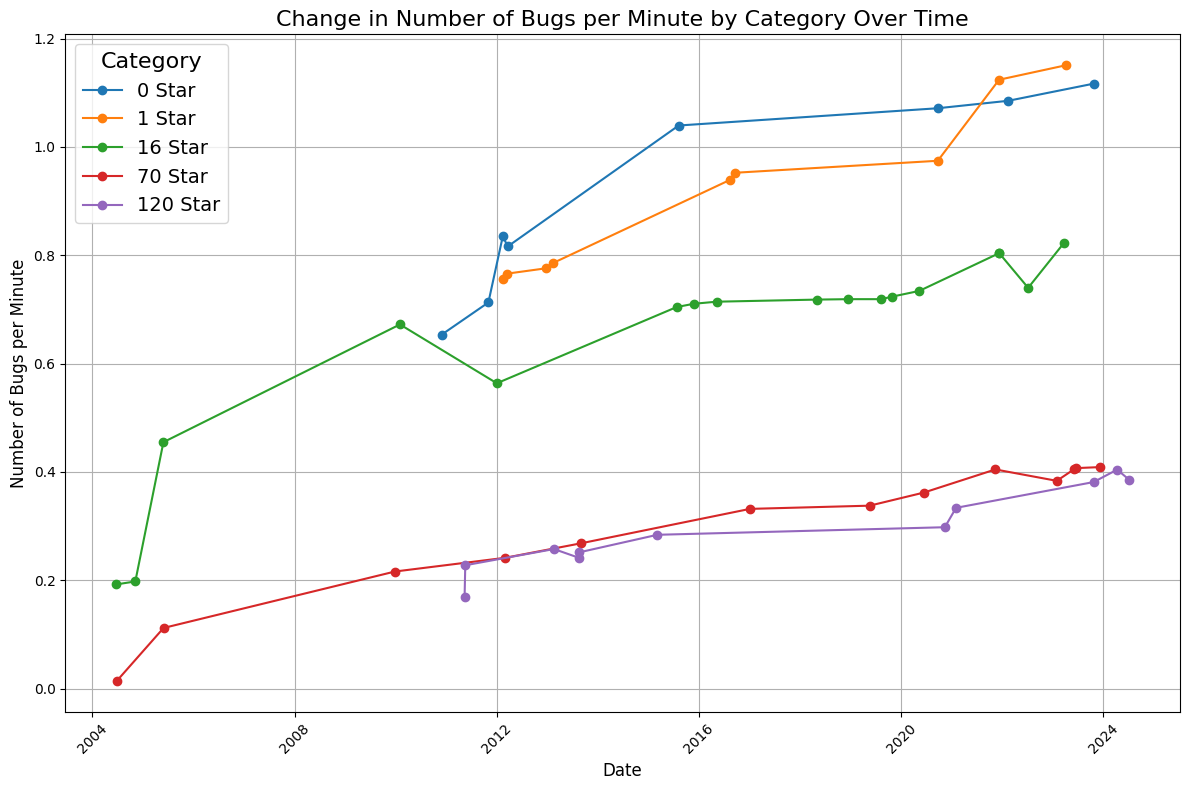

In [115]:
import matplotlib.pyplot as plt

# clear_time列の時間を「分」に変換する関数
def convert_time_to_minutes(time_str):
    time_parts = time_str.split(':')
    if len(time_parts) == 3:  # HH:MM:SS形式の場合
        hours, minutes, seconds = map(int, time_parts)
    elif len(time_parts) == 2:  # MM:SS形式の場合
        hours = 0
        minutes, seconds = map(int, time_parts)
    else:
        raise ValueError(f"Invalid time format: {time_str}")
    
    total_minutes = hours * 60 + minutes + seconds / 60
    return total_minutes

# 各ビデオIDの出現回数とクリアタイムを計算する
video_results = df1.groupby('video_id').apply(lambda x: {
    'count': len(x),
    'clear_time_minutes': convert_time_to_minutes(x['clear_time'].iloc[0])
})

# 出現順を保持するために元の順序を取得
video_ids_in_order = df1['video_id'].unique()

# 結果を格納するリスト
results = []

# カテゴリごとのresultを計算し、リストに保存
for video_id in video_ids_in_order:
    if video_id in video_results:
        data = video_results[video_id]
        x = data['count']  # ビデオIDの出現回数
        y = data['clear_time_minutes']  # ビデオIDに対応する最初のクリアタイム
        if y != 0:  # ゼロ除算を防ぐ
            result = x / y
            # カテゴリ部分を抽出（最初の'-'の前）
            category = video_id.split('-')[0]
            # 日付部分を抽出（最後の3つの'-'で区切られた部分）
            date_parts = video_id.split('-')[-3:]
            date_str = '-'.join(date_parts)
            # 日付部分をdatetime型に変換
            try:
                date = pd.to_datetime(date_str)
                # カテゴリ、日付、resultをリストに追加
                results.append((category, date, result))
            except ValueError:
                print(f"Invalid date format in video_id: {video_id}")
        else:
            print(f"Video ID: {video_id} has a total clear time of 0 minutes. Cannot calculate x/y.")



# 結果をデータフレームに変換
results_df = pd.DataFrame(results, columns=['Category', 'Date', 'Result'])

# 各カテゴリごとにプロット
plt.figure(figsize=(12, 8))

categories = results_df['Category'].unique()

for category in categories:
    # 各カテゴリごとのデータを抽出
    category_data = results_df[results_df['Category'] == category]
    # 日付順にソート
    category_data = category_data.sort_values('Date')
    # 折れ線グラフの作成
    plt.plot(category_data['Date'], category_data['Result'], marker='o', linestyle='-', label=f'{category} Star')

# グラフのタイトルやラベルの設定
plt.title('Change in Number of Bugs per Minute by Category Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Bugs per Minute', fontsize=12)
plt.legend(title="Category", fontsize=14, title_fontsize=16)
plt.grid(True)

# グラフの表示
plt.xticks(rotation=45)  # 日付が読みやすくなるように回転
plt.tight_layout()
plt.show()

# 各動画ごとのバグ数

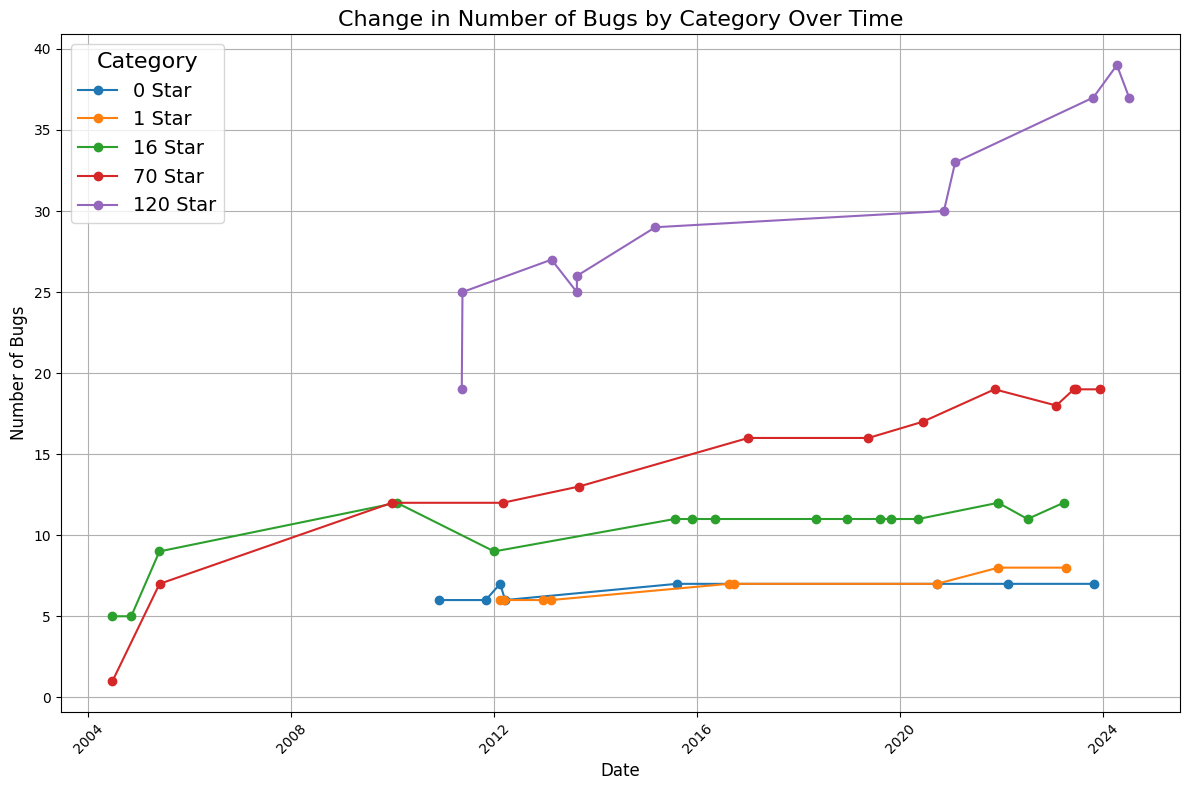

In [116]:
# 結果を格納するリスト
results = []

# カテゴリごとのresultを計算し、リストに保存
for video_id in video_ids_in_order:
    if video_id in video_results:
        data = video_results[video_id]
        result = data['count']  # ビデオIDの出現回数
        # カテゴリ部分を抽出（最初の'-'の前）
        category = video_id.split('-')[0]
        # 日付部分を抽出（最後の3つの'-'で区切られた部分）
        date_parts = video_id.split('-')[-3:]
        date_str = '-'.join(date_parts)
        # 日付部分をdatetime型に変換
        try:
            date = pd.to_datetime(date_str)
            # カテゴリ、日付、resultをリストに追加
            results.append((category, date, result))
        except ValueError:
            print(f"Invalid date format in video_id: {video_id}")



# 結果をデータフレームに変換
results_df = pd.DataFrame(results, columns=['Category', 'Date', 'Result'])

# 各カテゴリごとにプロット
plt.figure(figsize=(12, 8))

categories = results_df['Category'].unique()

for category in categories:
    # 各カテゴリごとのデータを抽出
    category_data = results_df[results_df['Category'] == category]
    # 日付順にソート
    category_data = category_data.sort_values('Date')
    # 折れ線グラフの作成
    plt.plot(category_data['Date'], category_data['Result'], marker='o', linestyle='-', label=f'{category} Star')

# グラフのタイトルやラベルの設定
plt.title('Change in Number of Bugs by Category Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Bugs', fontsize=12)
plt.legend(title="Category", fontsize=14, title_fontsize=16)
plt.grid(True)

# グラフの表示
plt.xticks(rotation=45)  # 日付が読みやすくなるように回転
plt.tight_layout()
plt.show()

# 各カテゴリごとのバグ密度

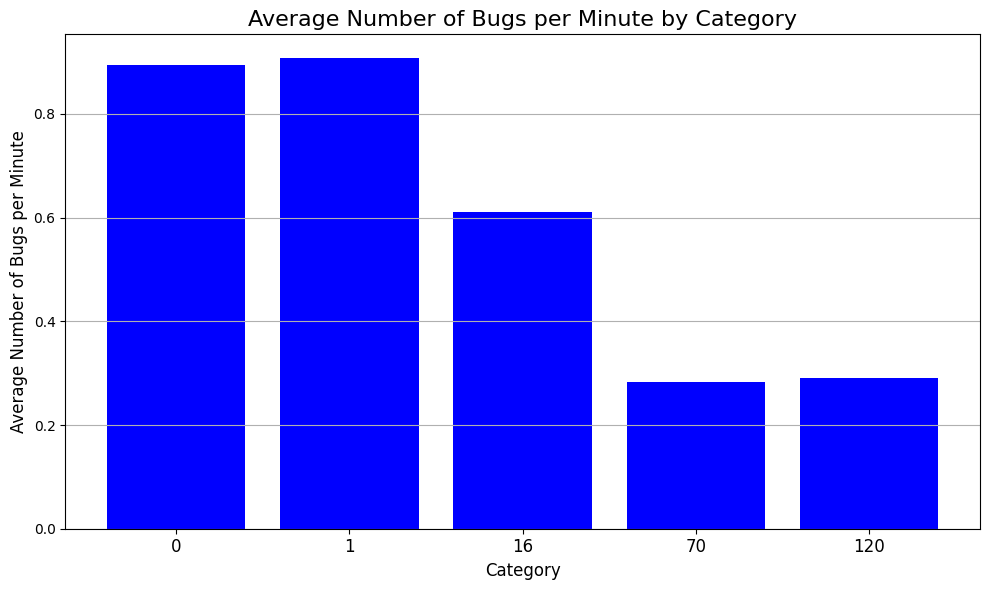

In [117]:
# ビデオIDごとの出現回数とクリアタイムの合計を計算
results = []
for video_id in df1['video_id'].unique():
    video_subset = df1[df1['video_id'] == video_id]
    x = len(video_subset)  # ビデオIDの出現回数
    y = convert_time_to_minutes(video_subset['clear_time'].iloc[0])  # 最初のクリアタイムを時間に変換
    
    if y != 0:  # ゼロ除算を防ぐためにチェック
        # カテゴリ部分を抽出（最初の'-'の前）
        category = video_id.split('-')[0]
        
        # カテゴリとX, Yをリストに追加
        results.append((category, x, y))

# 結果をデータフレームに変換
results_df = pd.DataFrame(results, columns=['Category', 'X', 'Y'])

# カテゴリを数値として扱うために変換し、ソート
results_df['Category'] = results_df['Category'].astype(int)
results_df = results_df.sort_values('Category')

# 各カテゴリごとの X の合計と Y の合計を計算
category_totals = results_df.groupby('Category').agg({'X': 'sum', 'Y': 'sum'}).reset_index()

# 各カテゴリごとの結果（Xの合計 / Yの合計）を計算
category_totals['Result'] = category_totals['X'] / category_totals['Y']

# 棒グラフの作成
plt.figure(figsize=(10, 6))
plt.bar(category_totals['Category'].astype(str), category_totals['Result'], color='b')

# グラフのタイトルやラベルの設定
plt.title('Average Number of Bugs per Minute by Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Average Number of Bugs per Minute', fontsize=12)
plt.grid(True, axis='y')

# カテゴリ名が読みやすくなるように設定
plt.xticks(fontsize=12)
plt.tight_layout()

# グラフの表示
plt.show()

# 各カテゴリごとのバグ数の平均

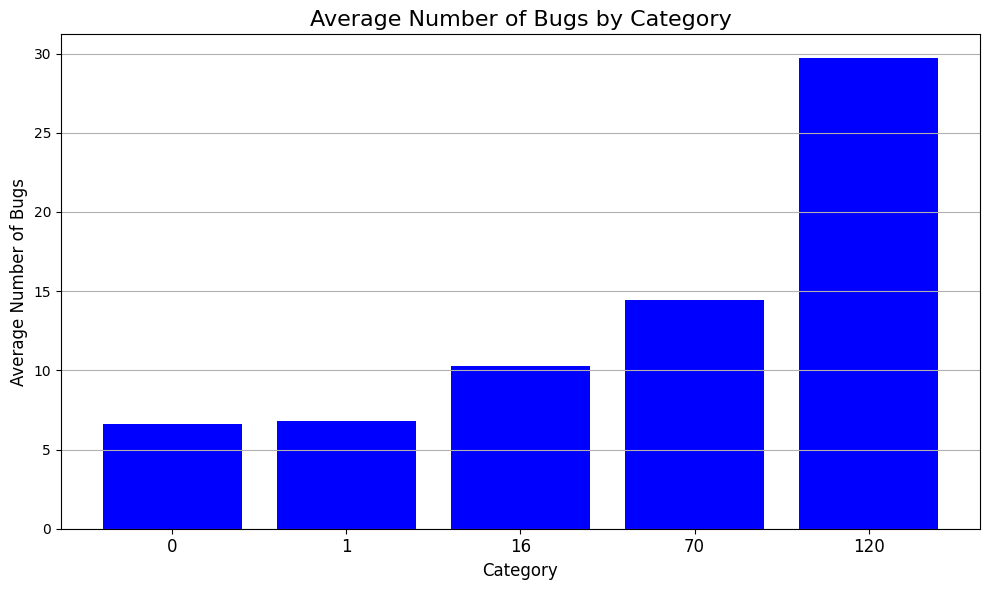

In [118]:
results = []
for video_id in df1['video_id'].unique():
    video_subset = df1[df1['video_id'] == video_id]
    result = len(video_subset)  # ビデオIDの出現回数
    
    # カテゴリ部分を抽出（最初の'-'の前）
    category = video_id.split('-')[0]
    
    # カテゴリとresultをリストに追加
    results.append((category, result))

# 結果をデータフレームに変換
results_df = pd.DataFrame(results, columns=['Category', 'Result'])

# カテゴリを数値として扱うために変換し、ソート
results_df['Category'] = results_df['Category'].astype(int)
results_df = results_df.sort_values('Category')

# 各カテゴリごとの Result の合計と要素数を計算し、平均を求める
category_totals = results_df.groupby('Category').agg(
    total_result=('Result', 'sum'),  # 合計
    count=('Result', 'size')         # 要素数
).reset_index()

# 平均を計算 (合計 / 要素数)
category_totals['Average_Result'] = category_totals['total_result'] / category_totals['count']

# 棒グラフの作成
plt.figure(figsize=(10, 6))
plt.bar(category_totals['Category'].astype(str), category_totals['Average_Result'], color='b')

# グラフのタイトルやラベルの設定
plt.title('Average Number of Bugs by Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Average Number of Bugs', fontsize=12)
plt.grid(True, axis='y')

# カテゴリ名が読みやすくなるように設定
plt.xticks(fontsize=12)
plt.tight_layout()

# グラフの表示
plt.show()

# 全動画のバグ密度

In [119]:
# 結果を格納するリスト（新しく初期化）
results = []

# 各ビデオIDの出現回数とクリアタイムを計算し、リストに追加
for video_id in df1['video_id'].unique():
    video_subset = df1[df1['video_id'] == video_id]
    x = len(video_subset)  # ビデオIDの出現回数
    y = convert_time_to_minutes(video_subset['clear_time'].iloc[0])  # 最初のクリアタイムを時間に変換
    
    if y != 0:  # ゼロ除算を防ぐためにチェック
        # 全データの X と Y をリストに追加
        results.append((x, y))

# 結果をデータフレームに変換
results_df = pd.DataFrame(results, columns=['X', 'Y'])

# 全データに対する X の合計と Y の合計を計算
total_x = results_df['X'].sum()
total_y = results_df['Y'].sum()

# X / Y を計算（ゼロ除算を防ぐ）
if total_y != 0:
    overall_result = total_x / total_y
else:
    overall_result = None  # もし Y が全てゼロの場合の処理

# 結果を表示
print(f"Total Bugs: {total_x}")
print(f"Total Time(Minute): {total_y}")
print(f"Average Number of Bugs per Minute: {overall_result}")

Total Bugs: 804
Total Time(Minute): 2204.4333333333334
Average Number of Bugs per Minute: 0.36471958023981976


# 全動画のバグ数の平均

In [120]:
# 結果を格納するリスト（新しく初期化）
results = []
num_videos = len(df1['video_id'].unique())

# 各ビデオIDの出現回数とクリアタイムを計算し、リストに追加
for video_id in df1['video_id'].unique():
    video_subset = df1[df1['video_id'] == video_id]
    result = len(video_subset)  # ビデオIDの出現回数
    
    # 全データの result をリストに追加
    results.append(result)

# 結果をデータフレームに変換
results_df = pd.DataFrame(results, columns=['Result'])

# 全データに対する Result の合計を動画数で割って平均を求める
total_result = results_df['Result'].sum() / num_videos

# 結果を表示
print(f"Average Number of Bugs: {total_result}")

Average Number of Bugs: 13.862068965517242


# 各カテゴリのごとのバグ密度の箱ひげ図

<Figure size 1200x800 with 0 Axes>

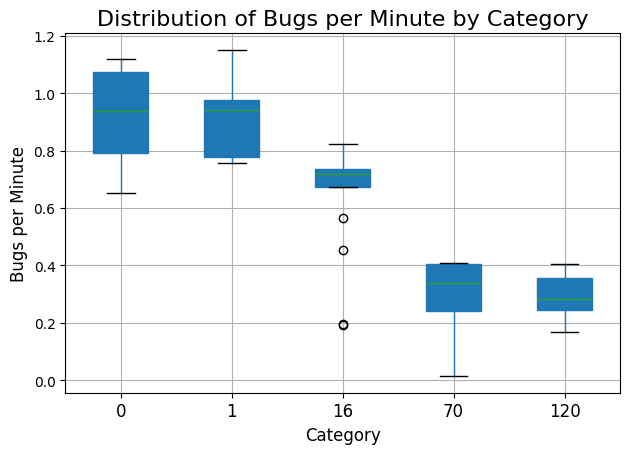

In [121]:
# 結果を格納するリスト（新しく初期化）
results = []

# ビデオIDごとの出現回数とクリアタイムの合計を計算
for video_id in df1['video_id'].unique():
    video_subset = df1[df1['video_id'] == video_id]
    x = len(video_subset)  # ビデオIDの出現回数
    y = convert_time_to_minutes(video_subset['clear_time'].iloc[0])  # 最初のクリアタイムを時間に変換
    
    if y != 0:  # ゼロ除算を防ぐためにチェック
        result = x / y
        # カテゴリ部分を抽出（最初の'-'の前）
        category = video_id.split('-')[0]
        # カテゴリと結果をリストに追加
        results.append((category, result))

# 結果をデータフレームに変換
results_df = pd.DataFrame(results, columns=['Category', 'Result'])

# カテゴリを数値として扱うために変換し、ソート
results_df['Category'] = results_df['Category'].astype(int)
results_df = results_df.sort_values('Category')

# 箱ひげ図の作成
plt.figure(figsize=(12, 8))
results_df.boxplot(column='Result', by='Category', grid=True, patch_artist=True)

# グラフのタイトルやラベルの設定
plt.title('Distribution of Bugs per Minute by Category', fontsize=16)
plt.suptitle('')  # Suptitle を削除
plt.xlabel('Category', fontsize=12)
plt.ylabel('Bugs per Minute', fontsize=12)
plt.grid(True)

# カテゴリ名が読みやすくなるように設定
plt.xticks(fontsize=12)
plt.tight_layout()

# グラフの表示
plt.show()

# 各カテゴリごとのバグ数の箱ひげ図

<Figure size 1200x800 with 0 Axes>

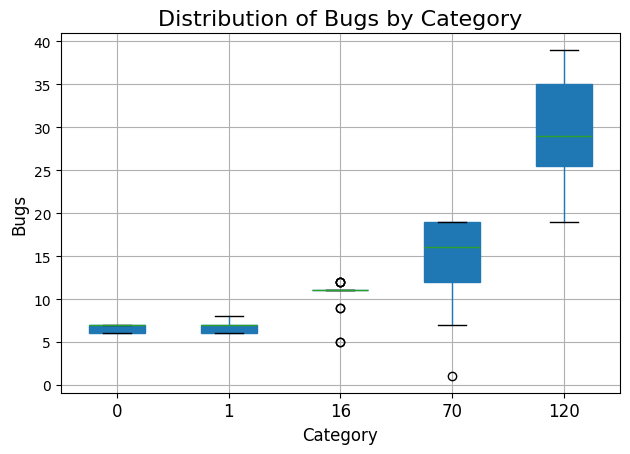

In [122]:
# 結果を格納するリスト（新しく初期化）
results = []

# ビデオIDごとの出現回数とクリアタイムの合計を計算
for video_id in df1['video_id'].unique():
    video_subset = df1[df1['video_id'] == video_id]
    result = len(video_subset)  # ビデオIDの出現回数
    
    # カテゴリ部分を抽出（最初の'-'の前）
    category = video_id.split('-')[0]
    # カテゴリと結果をリストに追加
    results.append((category, result))

# 結果をデータフレームに変換
results_df = pd.DataFrame(results, columns=['Category', 'Result'])

# カテゴリを数値として扱うために変換し、ソート
results_df['Category'] = results_df['Category'].astype(int)
results_df = results_df.sort_values('Category')

# 箱ひげ図の作成
plt.figure(figsize=(12, 8))
results_df.boxplot(column='Result', by='Category', grid=True, patch_artist=True)

# グラフのタイトルやラベルの設定
plt.title('Distribution of Bugs by Category', fontsize=16)
plt.suptitle('')  # Suptitle を削除
plt.xlabel('Category', fontsize=12)
plt.ylabel('Bugs', fontsize=12)
plt.grid(True)

# カテゴリ名が読みやすくなるように設定
plt.xticks(fontsize=12)
plt.tight_layout()

# グラフの表示
plt.show()

# コリジョン抜けの数チェック

In [123]:
# シート1の'壁抜けチェック'列の各要素が何回現れるかをカウント
kabenuke_check = df1['壁抜けチェック'].value_counts()

# カウント結果を出力
print(kabenuke_check)

壁抜けチェック
1    711
0     93
Name: count, dtype: int64
